## Notebook 2: Feature Engineering - Phase 2

### Objective
1. Load the dataset produced in Phase 1
2. Compute technical indicator features
3. Construct lag features (t-1, t-2, t-5) to give the RF temporal context
4. Create the binary target variable 
5. Handle missing values introduced by rolling windows
6. Analyse feature distributions and check for multicollinearity
7. Save the final feature matrix ready for Phase 3 (modelling)

**Why these features?**  
Krauss et al. (2017) used only lagged returns as features. Our approach extends this by incorporating technical indicators, which encode momentum, trend, volatility and volume, giving the RF a richer signal space to learn from, and constituting a direct methodological contribution over the benchmark.

## 1. Imports & Load Data

In [3]:
%pip install ta
%pip install pandas numpy matplotlib seaborn scikit-learn ta

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 'ta' library - technical indicator library
import ta

pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Configuration - must match Phase 1 settings
TICKER     = 'SPY'
TRAIN_END  = '2020-12-31'
TEST_START = '2021-01-01'

print('All dependencies loaded.')

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
All dependencies loaded.


In [10]:
# Anchor paths to the notebook's directory
BASE_DIR = Path(__file__).parent if '__file__' in dir() else Path.cwd()

FIG_DIR = BASE_DIR / 'figures' / 'EDA'
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = BASE_DIR / 'data'
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Load the clean dataset saved at end of Phase 1
df = pd.read_csv(DATA_DIR / 'SPY_clean_data.csv', index_col=0, parse_dates=True)

# Ensure correct dtypes
df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)

print(f'Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Date range: {df.index[0].date()} → {df.index[-1].date()}')
print(f'\nColumns available: {list(df.columns)}')
df[['Open', 'High', 'Low', 'Close', 'Volume']].head()

Loaded dataset: 2263 rows, 11 columns
Date range: 2015-01-05 → 2023-12-29

Columns available: ['Close', 'High', 'Low', 'Open', 'Volume', 'log_return', 'simple_return', 'vol_20d', 'VIX', 'year', 'month']


,Open,High,Low,Close,Volume
Date,,,,,
2015-01-05,169.0816,169.2472,166.7462,167.0526,169632600
2015-01-06,167.3590,167.8807,164.6841,165.4791,209151400
2015-01-07,166.8042,167.8807,166.3570,167.5412,125346700
2015-01-08,168.9490,170.7295,168.9325,170.5142,147217800
2015-01-09,170.9283,170.9448,168.5349,169.1478,158567300


## 2. Technical Indicator Features

We compute indicators across four categories, each capturing a different dimension of market behaviour:

| Category | Indicators | What they capture |
|----------|-----------|-------------------|
| Momentum | RSI, MACD, MACD signal, MACD diff | Overbought/oversold, trend strength |
| Trend | EMA(10), EMA(20), EMA(50), price vs EMA ratio | Direction of the trend |
| Volatility | Bollinger Band width, %B, ATR | Market uncertainty, breakout potential |
| Volume | OBV, Volume ratio (vs 20-day avg) | Buying/selling pressure confirmation |

**No look-ahead bias:** All indicators are computed using only past data. No future values are used in any calculation.

In [11]:
# Working on a copy 
features = df.copy()

# Convenience references
close  = features['Close']
high   = features['High']
low    = features['Low']
volume = features['Volume']
open_  = features['Open']

In [12]:
# 2a. MOMENTUM indicators

# RSI (14-day) - Relative Strength Index
# Ranges 0–100. >70 = overbought, <30 = oversold.
features['rsi_14'] = ta.momentum.RSIIndicator(close=close, window=14).rsi()

# MACD - Moving Average Convergence Divergence
# Standard parameters: fast=12, slow=26, signal=9
macd_obj = ta.trend.MACD(close=close, window_fast=12, window_slow=26, window_sign=9)
features['macd']        = macd_obj.macd()            # MACD line
features['macd_signal'] = macd_obj.macd_signal()     # Signal line
features['macd_diff']   = macd_obj.macd_diff()       # Histogram (MACD - signal)

# Stochastic Oscillator (14-day)
# %K measures close relative to recent high-low range
stoch_obj = ta.momentum.StochasticOscillator(high=high, low=low, close=close, window=14, smooth_window=3)
features['stoch_k'] = stoch_obj.stoch()
features['stoch_d'] = stoch_obj.stoch_signal()

# Rate of Change (10-day)
# Percentage change in price over N periods
features['roc_10'] = ta.momentum.ROCIndicator(close=close, window=10).roc()

print('Momentum indicators computed: RSI, MACD, Stochastic, ROC')

Momentum indicators computed: RSI, MACD, Stochastic, ROC


In [13]:
# 2b. TREND indicators

# Exponential Moving Averages
features['ema_10'] = ta.trend.EMAIndicator(close=close, window=10).ema_indicator()
features['ema_20'] = ta.trend.EMAIndicator(close=close, window=20).ema_indicator()
features['ema_50'] = ta.trend.EMAIndicator(close=close, window=50).ema_indicator()

# Price relative to EMA - normalised, removes price scale
# Positive = price above EMA (bullish), Negative = below (bearish)
features['price_vs_ema20'] = (close - features['ema_20']) / features['ema_20']
features['price_vs_ema50'] = (close - features['ema_50']) / features['ema_50']

# EMA crossover signal - positive when short-term > long-term (bullish)
features['ema_cross_10_50'] = (features['ema_10'] - features['ema_50']) / features['ema_50']

# ADX - Average Directional Index (trend strength, not direction)
# >25 = strong trend, <20 = weak/ranging
adx_obj = ta.trend.ADXIndicator(high=high, low=low, close=close, window=14)
features['adx']    = adx_obj.adx()
features['adx_pos'] = adx_obj.adx_pos()   # +DI
features['adx_neg'] = adx_obj.adx_neg()   # -DI

print('Trend indicators computed: EMA(10/20/50), price/EMA ratios, EMA crossover, ADX')

Trend indicators computed: EMA(10/20/50), price/EMA ratios, EMA crossover, ADX


In [14]:
# 2c. VOLATILITY indicators

# Bollinger Bands (20-day, 2 std devs)
bb_obj = ta.volatility.BollingerBands(close=close, window=20, window_dev=2)
features['bb_upper']  = bb_obj.bollinger_hband()
features['bb_lower']  = bb_obj.bollinger_lband()
features['bb_middle'] = bb_obj.bollinger_mavg()

# BB Width - measures volatility (wider bands = higher volatility)
features['bb_width']  = bb_obj.bollinger_wband()

# %B - position of price within the bands (0=lower, 1=upper, >1 or <0 = breakout)
features['bb_pct_b']  = bb_obj.bollinger_pband()

# ATR - Average True Range (14-day)
# Absolute measure of volatility - normalise by close price for scale-independence
features['atr_14'] = ta.volatility.AverageTrueRange(high=high, low=low, close=close, window=14).average_true_range()
features['atr_pct'] = features['atr_14'] / close  # Normalised ATR

print('Volatility indicators computed: Bollinger Bands (width, %B), ATR (raw + normalised)')

Volatility indicators computed: Bollinger Bands (width, %B), ATR (raw + normalised)


In [15]:
# 2d. VOLUME indicators

# On-Balance Volume (OBV)
# Cumulative volume indicator - rising OBV with rising price confirms trend
features['obv'] = ta.volume.OnBalanceVolumeIndicator(close=close, volume=volume).on_balance_volume()

# OBV normalised (z-score over 20-day rolling window) - removes drift
features['obv_zscore'] = (
    (features['obv'] - features['obv'].rolling(20).mean()) /
    (features['obv'].rolling(20).std() + 1e-8)
)

# Volume ratio - today's volume vs 20-day average
# >1.5 = unusually high volume (confirms breakouts or reversals)
features['vol_ratio'] = volume / volume.rolling(20).mean()

# VIX (already loaded in Phase 1 and merged)
# Used as a market-wide fear/uncertainty proxy
# Already in features as 'VIX'

print('Volume indicators computed: OBV (raw + z-score), volume ratio')
print(f'\nTotal features so far: {features.shape[1]} columns')

Volume indicators computed: OBV (raw + z-score), volume ratio

Total features so far: 37 columns


## 3. Lag Features

Random Forest has no built-in memory, it treats each row as independent. Lag features give the model temporal context by making previous days' values explicit inputs.

Following Krauss et al. (2017) who used lagged returns as their primary feature set, we add lags of key features at t-1, t-2, and t-5 (one week back).

In [16]:
# 3. Lag features

# Features to lag - returns and key indicators
lag_targets = ['log_return', 'rsi_14', 'macd_diff', 'bb_pct_b', 'atr_pct', 'vol_ratio', 'VIX']
lag_periods  = [1, 2, 5]  # t-1 (yesterday), t-2, t-5 (last week)

for col in lag_targets:
    if col in features.columns:
        for lag in lag_periods:
            features[f'{col}_lag{lag}'] = features[col].shift(lag)

# Also add lagged simple returns directly (mirrors Krauss et al. feature set)
for lag in [1, 2, 3, 4, 5]:
    features[f'return_lag{lag}'] = features['simple_return'].shift(lag)

n_lag_cols = sum(1 for c in features.columns if 'lag' in c)
print(f'Lag features added: {n_lag_cols} columns')
print(f'Total features now: {features.shape[1]} columns')

Lag features added: 26 columns
Total features now: 63 columns


## 4. Target Variable

We frame this as a **binary classification** problem, predicting whether the next trading day's return is positive (Up=1) or negative/flat (Down=0).

This is consistent with Krauss et al. (2017) who predicted directional outperformance, and means Sharpe ratio and Win ratio are both directly interpretable from the RF's output.

In [17]:
# 4. Target variable - next-day direction

# Shift returns back by 1 to get NEXT day's return as the target
# At row t, target = sign of return at t+1
features['target'] = (features['simple_return'].shift(-1) > 0).astype(int)

# Class balance check - important for RF
class_counts = features['target'].value_counts()
print('Target variable distribution:')
print(f'  Up   (1): {class_counts.get(1, 0)} days ({class_counts.get(1, 0)/len(features)*100:.1f}%)')
print(f'  Down (0): {class_counts.get(0, 0)} days ({class_counts.get(0, 0)/len(features)*100:.1f}%)')
print()
print('Note: Near 50/50 split is expected and healthy for a daily S&P 500 direction problem.')
print('Significant imbalance would require class_weight="balanced" in RF.')

Target variable distribution:
  Up   (1): 1225 days (54.1%)
  Down (0): 1038 days (45.9%)

Note: Near 50/50 split is expected and healthy for a daily S&P 500 direction problem.
Significant imbalance would require class_weight="balanced" in RF.


## 5. Data Cleaning - Handling NaN Values

In [18]:
# 5. Drop NaNs introduced by rolling windows and lags

# The longest rolling window is EMA(50) + lag(5) = ~55 rows lost at the start
# The target shift(-1) drops the very last row

print(f'Shape before dropna: {features.shape}')
print(f'NaN counts per column (top 10):\n{features.isnull().sum().sort_values(ascending=False).head(10)}')

features.dropna(inplace=True)

print(f'\nShape after dropna: {features.shape}')
print(f'Rows lost to rolling windows + lags: {len(df) - len(features)}')

Shape before dropna: (2263, 64)
NaN counts per column (top 10):
ema_cross_10_50    49
price_vs_ema50     49
ema_50             49
macd_diff_lag5     38
macd_diff_lag2     35
macd_diff_lag1     34
macd_diff          33
macd_signal        33
macd               25
vol_ratio_lag5     24
dtype: int64

Shape after dropna: (2214, 64)
Rows lost to rolling windows + lags: 49


## 6. Define Final Feature Matrix

listing the features going into the model. Raw OHLCV columns and intermediate calculations are excluded 

In [19]:
# 6. Define the feature set explicitly

# Raw OHLCV and intermediate columns to EXCLUDE from model inputs
exclude_cols = [
    'Open', 'High', 'Low', 'Close', 'Volume',   # raw price/volume - not features
    'simple_return',                              # used to build target - data leakage risk
    'log_return',                                 # lagged version included separately
    'bb_upper', 'bb_lower', 'bb_middle',          # raw BB levels - scale-dependent
    'ema_10', 'ema_20', 'ema_50',                # raw EMA levels - scale-dependent
    'atr_14',                                     # raw ATR - use normalised version
    'obv',                                        # raw OBV - use z-score version
    'vol_20d',                                    # computed in Phase 1 - redundant with atr_pct
    'year', 'month',                              # calendar artefacts from Phase 1 EDA
    'target',                                     # target variable - not a feature!
]

# Everything else is a feature
feature_cols = [c for c in features.columns if c not in exclude_cols]

print(f'Final feature count: {len(feature_cols)}')
print('\nFeature list:')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {col}')

Final feature count: 45

Feature list:
   1. VIX
   2. rsi_14
   3. macd
   4. macd_signal
   5. macd_diff
   6. stoch_k
   7. stoch_d
   8. roc_10
   9. price_vs_ema20
  10. price_vs_ema50
  11. ema_cross_10_50
  12. adx
  13. adx_pos
  14. adx_neg
  15. bb_width
  16. bb_pct_b
  17. atr_pct
  18. obv_zscore
  19. vol_ratio
  20. log_return_lag1
  21. log_return_lag2
  22. log_return_lag5
  23. rsi_14_lag1
  24. rsi_14_lag2
  25. rsi_14_lag5
  26. macd_diff_lag1
  27. macd_diff_lag2
  28. macd_diff_lag5
  29. bb_pct_b_lag1
  30. bb_pct_b_lag2
  31. bb_pct_b_lag5
  32. atr_pct_lag1
  33. atr_pct_lag2
  34. atr_pct_lag5
  35. vol_ratio_lag1
  36. vol_ratio_lag2
  37. vol_ratio_lag5
  38. VIX_lag1
  39. VIX_lag2
  40. VIX_lag5
  41. return_lag1
  42. return_lag2
  43. return_lag3
  44. return_lag4
  45. return_lag5


In [20]:
# Build X and y
X = features[feature_cols].copy()
y = features['target'].copy()

# Train / test split - walk-forward, no shuffle
X_train = X.loc[:TRAIN_END]
X_test  = X.loc[TEST_START:]
y_train = y.loc[:TRAIN_END]
y_test  = y.loc[TEST_START:]

print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}   |  y_test : {y_test.shape}')
print(f'\nTrain Up%  : {y_train.mean()*100:.1f}%')
print(f'Test  Up%  : {y_test.mean()*100:.1f}%')

X_train: (1461, 45)  |  y_train: (1461,)
X_test : (753, 45)   |  y_test : (753,)

Train Up%  : 55.2%
Test  Up%  : 52.5%


## 7. Feature Analysis

Inspecting the features to check distributions

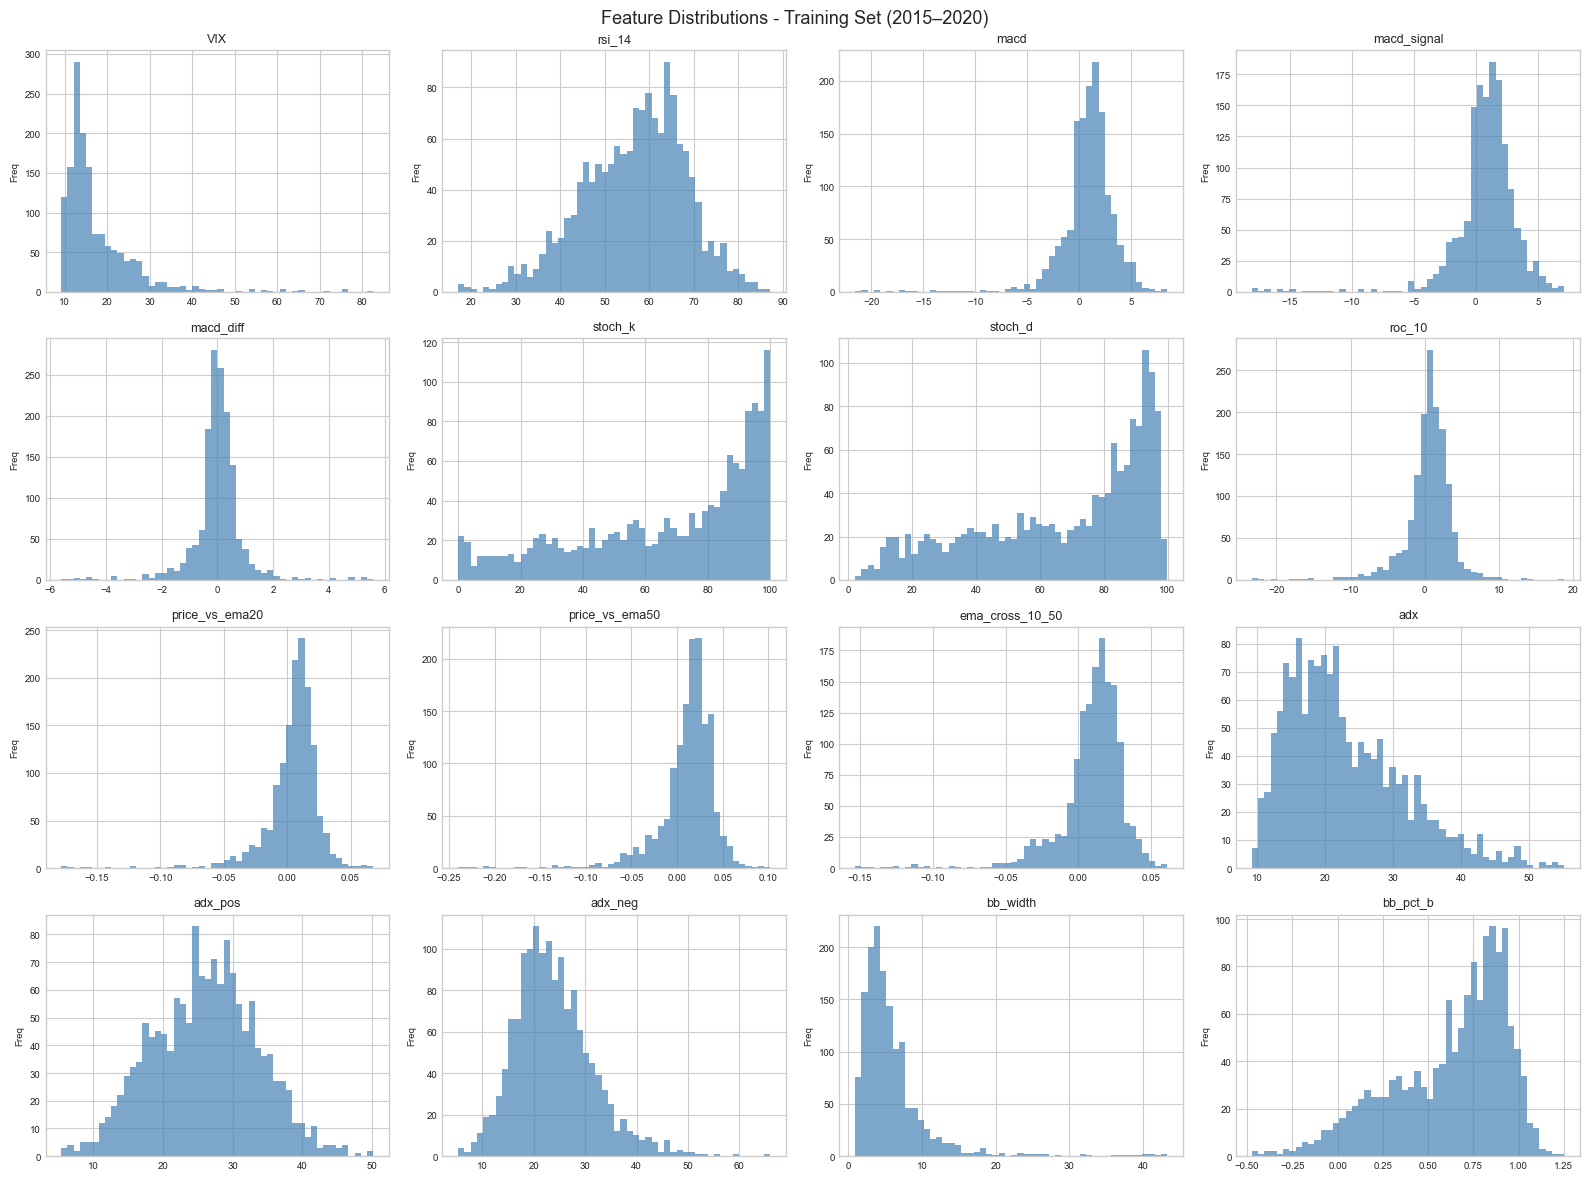

Figure 7 saved.


In [21]:
# Figure 1: Feature distributions (training set only)
# Plot first 16 non-lag features as a grid
base_features = [c for c in feature_cols if 'lag' not in c and 'return_lag' not in c][:16]

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(base_features):
    axes[i].hist(X_train[col].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='none')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Freq', fontsize=7)
    axes[i].tick_params(labelsize=7)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions - Training Set (2015–2020)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig7_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

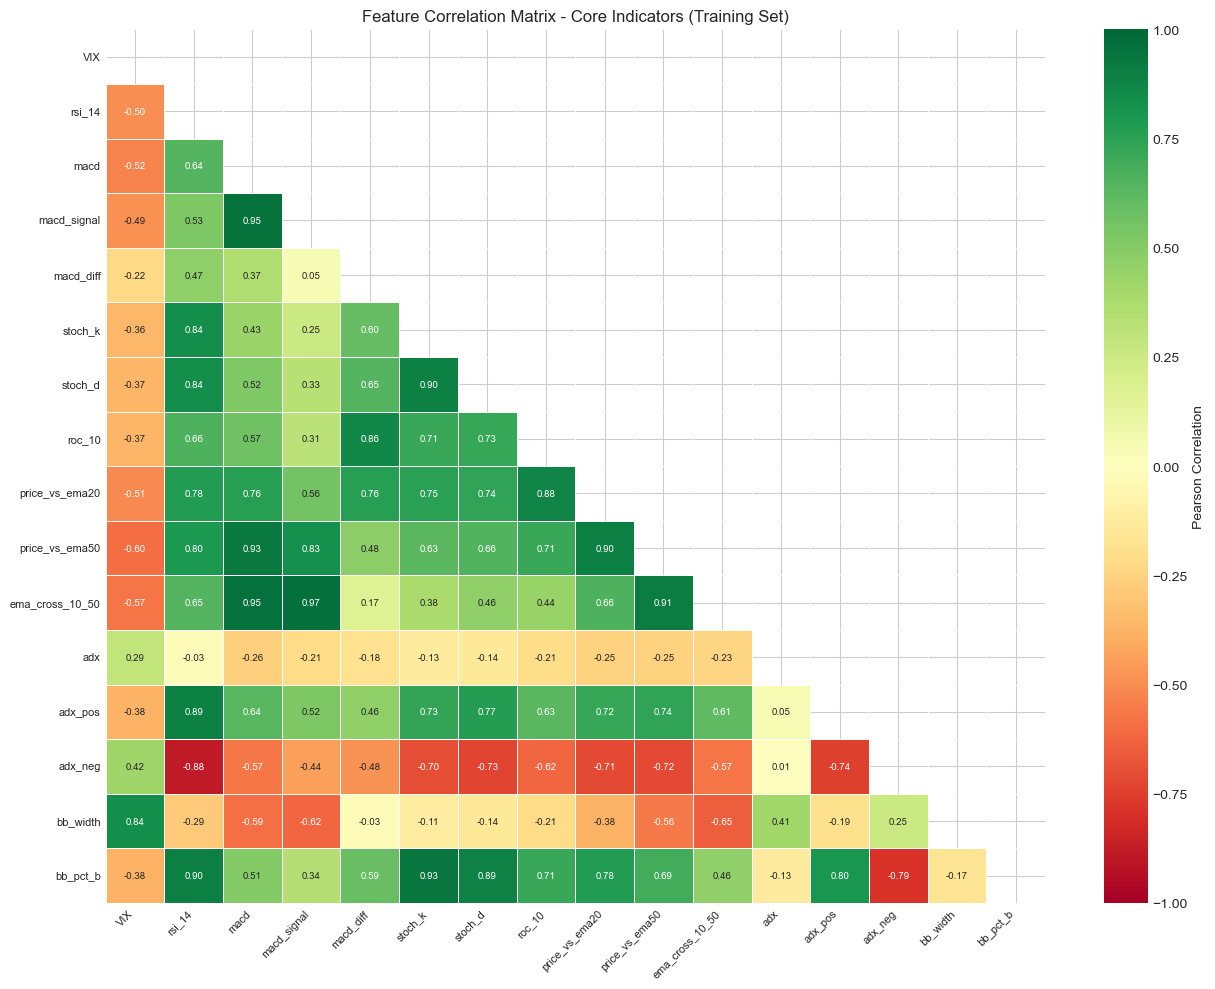


Highly correlated feature pairs (|r| > 0.85):
  macd_signal & macd: r = 0.947
  stoch_d & stoch_k: r = 0.904
  roc_10 & macd_diff: r = 0.862
  price_vs_ema20 & roc_10: r = 0.882
  price_vs_ema50 & macd: r = 0.925
  price_vs_ema50 & price_vs_ema20: r = 0.905
  ema_cross_10_50 & macd: r = 0.953
  ema_cross_10_50 & macd_signal: r = 0.965
  ema_cross_10_50 & price_vs_ema50: r = 0.910
  adx_pos & rsi_14: r = 0.892
  adx_neg & rsi_14: r = -0.885
  bb_pct_b & rsi_14: r = 0.901
  bb_pct_b & stoch_k: r = 0.933
  bb_pct_b & stoch_d: r = 0.887

Note: High correlation is less problematic for RF than for linear models
(RF randomly subsets features at each split, naturally reducing collinearity effects).


In [22]:
# Figure 2: Correlation heatmap - core features only
# Note: high correlation between features is less critical for RF than for linear
# models (RF uses random feature subsets), but it's worth documenting.

core_features = [c for c in feature_cols if 'lag' not in c][:16]
corr_matrix = X_train[core_features].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show lower triangle only
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 7},
    cbar_kws={'label': 'Pearson Correlation'}
)
ax.set_title('Feature Correlation Matrix - Core Indicators (Training Set)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig8_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag highly correlated pairs (|r| > 0.85)
print('\nHighly correlated feature pairs (|r| > 0.85):')
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], r))

if high_corr:
    for f1, f2, r in high_corr:
        print(f'  {f1} & {f2}: r = {r:.3f}')
    print('\nNote: High correlation is less problematic for RF than for linear models')
    print('(RF randomly subsets features at each split, naturally reducing collinearity effects).')
else:
    print('  No pairs above threshold - feature set is well-diversified.')

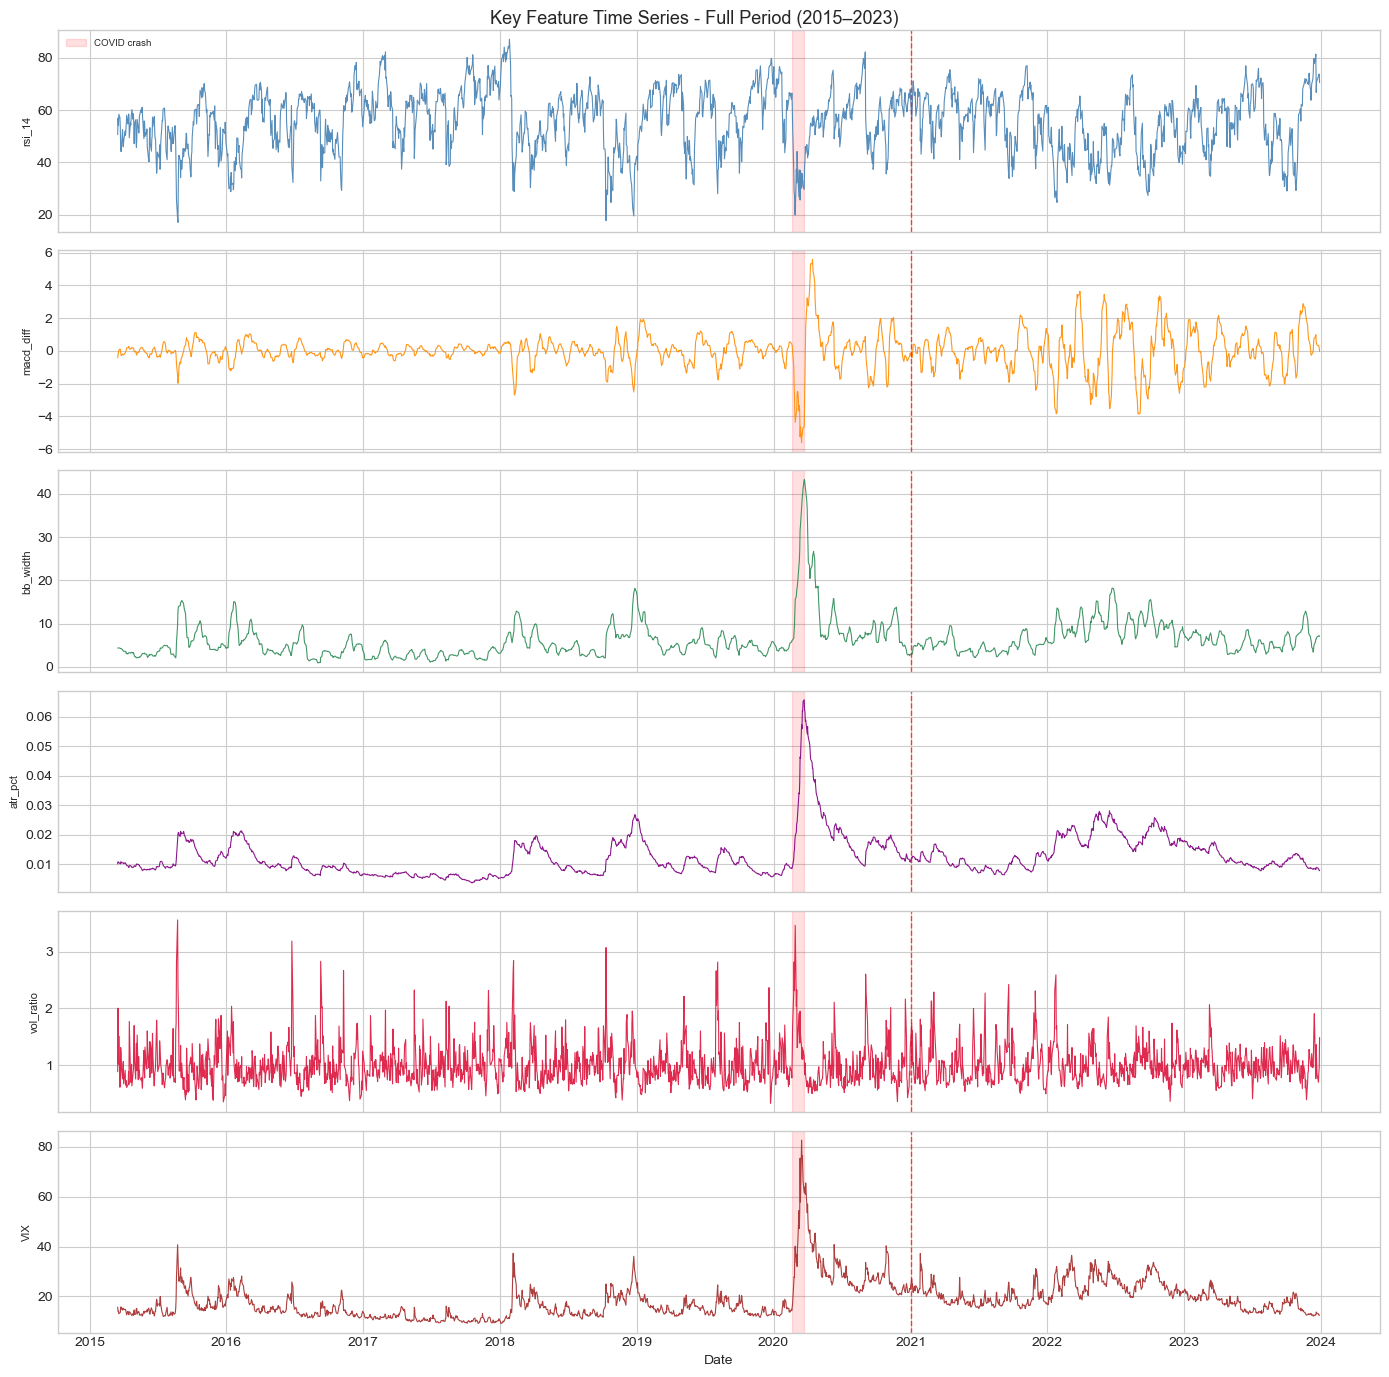

Figure 9 saved.


In [23]:
# Figure 3: Selected feature timelines - spot structural breaks
plot_features = ['rsi_14', 'macd_diff', 'bb_width', 'atr_pct', 'vol_ratio', 'VIX']
plot_features = [f for f in plot_features if f in X.columns]

fig, axes = plt.subplots(len(plot_features), 1, figsize=(14, 14), sharex=True)
fig.suptitle('Key Feature Time Series - Full Period (2015–2023)', fontsize=13)

colors = ['steelblue', 'darkorange', 'seagreen', 'purple', 'crimson', 'brown']

for i, (col, ax) in enumerate(zip(plot_features, axes)):
    ax.plot(X.index, X[col], color=colors[i % len(colors)], linewidth=0.8, alpha=0.9)
    ax.axvline(pd.Timestamp(TEST_START), color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_ylabel(col, fontsize=8)
    # Mark COVID crash
    ax.axvspan('2020-02-19', '2020-03-23', alpha=0.12, color='red', label='COVID crash')
    if i == 0:
        ax.legend(fontsize=7, loc='upper left')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig9_feature_timelines.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9 saved.')

## 8. Feature Summary Statistics

In [24]:
# Summary statistics - training set
summary = X_train.describe().T[['mean', 'std', 'min', 'max']]
summary.columns = ['Mean', 'Std', 'Min', 'Max']
print('Feature Summary Statistics (Training Set):')
print(summary.to_string())

Feature Summary Statistics (Training Set):
                   Mean     Std      Min      Max
VIX             17.5071  8.3911   9.1400  82.6900
rsi_14          56.6432 11.5468  16.9967  87.1910
macd             0.7936  2.8451 -21.5556   8.4813
macd_signal      0.7848  2.6501 -18.0403   7.1321
macd_diff        0.0088  0.9150  -5.6049   5.5956
stoch_k         67.0477 28.8308   0.0000 100.0000
stoch_d         67.0291 26.5497   2.1079  99.9377
roc_10           0.5310  3.2577 -23.2884  18.7979
price_vs_ema20   0.0044  0.0218  -0.1784   0.0681
price_vs_ema50   0.0112  0.0322  -0.2400   0.1023
ema_cross_10_50  0.0089  0.0235  -0.1535   0.0611
adx             22.9588  8.5311   9.2037  55.2022
adx_pos         26.0896  7.5693   5.3778  50.2480
adx_neg         23.8925  7.6804   5.2686  66.0563
bb_width         5.9546  5.0070   0.9454  43.2698
bb_pct_b         0.6227  0.3170  -0.4731   1.2524
atr_pct          0.0120  0.0078   0.0037   0.0658
obv_zscore       0.1944  1.2752  -3.3319   2.6465
vol_rat

## 9. Save Feature Matrix for Phase 3

In [25]:
# Save everything Phase 3 needs

# Full feature matrix + target
output = features[feature_cols + ['target']].copy()
output.to_csv(DATA_DIR / 'SPY_features.csv')

# Save the feature column list for reproducibility
pd.Series(feature_cols).to_csv(DATA_DIR / 'feature_cols.csv', index=False, header=False)

print('Saved:')
print(f'  data/SPY_features.csv    - {output.shape[0]} rows x {output.shape[1]} columns')
print(f'  data/feature_cols.csv    - {len(feature_cols)} feature names')
print()
print('Phase 2 complete. Ready for Phase 3 - Random Forest modelling.')

Saved:
  data/SPY_features.csv    - 2214 rows x 46 columns
  data/feature_cols.csv    - 45 feature names

Phase 2 complete. Ready for Phase 3 - Random Forest modelling.


---
## 10. Phase 2 Summary - Feature Selection

| Category | Features | Count |
|----------|----------|-------|
| Momentum | RSI, MACD, MACD signal, MACD diff, Stochastic %K/%D, ROC | 6 |
| Trend | Price/EMA ratios, EMA crossover, ADX (+DI, -DI) | 6 |
| Volatility | BB width, BB %B, ATR (normalised) | 3 |
| Volume | OBV z-score, Volume ratio | 2 |
| Market context | VIX | 1 |
| Lag features | Returns + key indicators at t-1, t-2, t-5 | ~26 |
| **Total** | | **~44** |


**Next:** Phase 3 - RF model, hyperparameter tuning with TimeSeriesSplit, out-of-sample evaluation